In [2]:
# We'll compute star counts (electrons) for a range of magnitudes using the user's slide parameters.
# This notebook cell defines reusable functions and then prints a table for the magnitudes shown in the image.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

# Physical constants
h = 6.626e-27     # Planck [erg*s]
c = 2.998e10      # speed of light [cm/s]

def telescope_area(diam_cm: float) -> float:
    """Geometric collecting area in cm^2 for a circular aperture of diameter diam_cm (cm)."""
    return pi * (diam_cm / 2)**2

def photon_energy(lam_A: float) -> float:
    """Photon energy (erg) at wavelength lam_A (Angstrom)."""
    lam_cm = lam_A * 1e-8
    return h * c / lam_cm

def star_counts_electrons(
    mag: float,
    F_lambda0: float = 6.3e-9,   # B band zeropoint [erg/cm^2/s/Å]
    lam_A: float = 4660,       # central wavelength [Å]
    dlam_A: float = 400,       # bandwidth [Å] ~ B
    diam_cm: float = 803.8,      # telescope diameter [cm]
    eta: float = 0.4,            # overall efficiency
    t_exp_s: float = 10e-3,      # exposure time [s]
    extinction_mag_per_airmass: float = 0.2,  # mag/airmass
    airmass: float = 1.2,        # airmass
) -> float:
    """
    Return total detected electrons from a star of magnitude 'mag' in exposure t_exp_s
    using an F_lambda zeropoint. Includes atmospheric extinction as mag += k * X.
    """
    # Geometric area
    A = telescope_area(diam_cm)
    # Effective observed magnitude (add atmospheric extinction in magnitudes)
    mag_eff = mag #+ extinction_mag_per_airmass * airmass
    # Flux density [erg/cm^2/s/Å] for the star at the ground
    F_lambda = F_lambda0 * 10**(-0.4 * mag_eff)
    # Integrated energy flux over the band
    F_band = F_lambda * dlam_A
    # Photon rate at the top of the detector per cm^2
    E_ph = photon_energy(lam_A)
    N_gamma_cm2_s = F_band / E_ph
    # Detected electrons
    e_detected = N_gamma_cm2_s * A * eta * t_exp_s
    return e_detected

# Reproduce the table for magnitudes seen in the screenshot
mags = [8.5, 9, 9.5]
counts = [round(star_counts_electrons(m)) for m in mags]

df = pd.DataFrame({"mag": mags, "star_electrons": counts})
df


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,mag,star_electrons
0,8.5,477693
1,9.0,301404
2,9.5,190173


In [3]:
#pi*3.35**2    


In [13]:
def sky_counts(mu_mag_as2, F_lambda0=6.3e-9, lam_A=4660, dlam_A=400,
               diam_cm=803.8, eta=0.4, t_exp_s=10e-3, ap_radius_as=3.35):
    A = telescope_area(diam_cm)                  # cm^2
    F_lambda = F_lambda0 * 10**(-0.4*mu_mag_as2) # erg/cm^2/s/Å/arcsec^2
    F_band   = F_lambda * dlam_A                 # erg/cm^2/s/arcsec^2
    E_ph     = h*c/(lam_A*1e-8)                  # erg
    N_sky    = F_band/E_ph                       # ph/cm^2/s/arcsec^2
    #Omega    = pi*ap_radius_as**2                # arcsec^2 #3.35
    Omega = 19200 *(0.009352**2)
   # npix= 1024
    sky_e_ap = N_sky * Omega * A * eta * t_exp_s
    return sky_e_ap
#sky_e_ap = sky_counts()
#22.7
mu_mag_as=np.asarray(np.linspace(-4.3, 22.7, num=10))
sky_e_ap=[]
for i in mu_mag_as:
    sky_e_ap.append(sky_counts(mu_mag_as2=i))

In [14]:
print(sky_e_ap)
print(mu_mag_as)

[105744916553.93391, 6672053174.114977, 420978095.29702294, 26561922.109293938, 1675943.9838369836, 105744.91655393384, 6672.0531741149725, 420.9780952970234, 26.561922109293953, 1.6759439838369838]
[-4.3 -1.3  1.7  4.7  7.7 10.7 13.7 16.7 19.7 22.7]


In [15]:
print(pi*3.35**2 )               # arcsec^2 #3.35
print(19200 *(0.09352**2))
df['star_electrons'][0]

35.25652355491145
167.92301568000002


477693

In [16]:
SNR1=[]
SNR2=[]
SNR3=[]
for j in df['star_electrons']:
    for i in sky_e_ap:
        if j == df['star_electrons'][0]:
            SNR1.append(j/(np.sqrt(j+(2*i))))
        if j == df['star_electrons'][1]:
            SNR2.append(j/(np.sqrt(j+(2*i))))
        if j == df['star_electrons'][2]:
            SNR3.append(j/(np.sqrt(j+(2*i))))

In [17]:
print((np.asarray(SNR1)).ravel())
print((np.asarray(SNR2)).ravel())
print((np.asarray(SNR3)).ravel())

[  1.03873231   4.13519845  16.45814803  65.24695596 244.10307438
 575.41562644 681.69753149 690.5450928  691.11495575 691.15095901]
[  0.65539625   2.60915188  10.38547928  41.23592465 157.69096854
 420.85769572 537.23889688 548.23752992 548.9543565  548.99967955]
[4.13527042e-01 1.64626982e+00 6.55322484e+00 2.60452274e+01
 1.01046399e+02 3.00066860e+02 4.21549325e+02 4.35126137e+02
 4.36027397e+02 4.36084451e+02]


Text(0, 0.5, 'SNR')

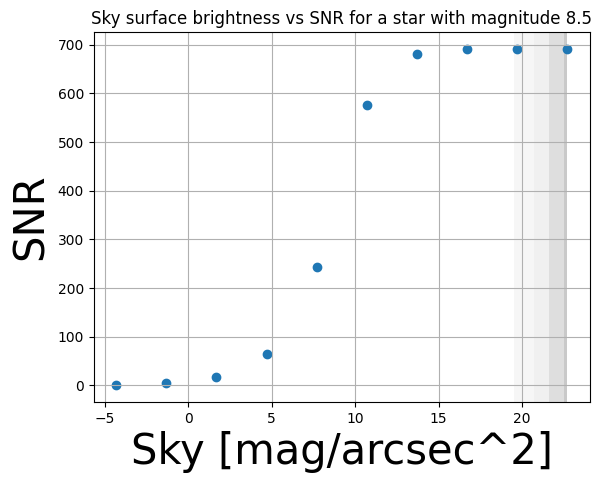

In [18]:
fig, ax = plt.subplots()

# Sky-surface-brightness bands (contiguous, using your ranges)
bands = [
    (22.5, 22.7, {'facecolor': '#2b2b2b', 'alpha': 0.25, 'label': 'Dark 22.5–22.7'}),
    (21.6, 22.5, {'facecolor': '#5a5a5a', 'alpha': 0.20, 'label': 'Dark gray 21.6–22.5'}),
    (20.7, 21.6, {'facecolor': '#b5b5b5', 'alpha': 0.20, 'label': 'Light gray 20.7–21.6'}),
    (19.5, 20.7, {'facecolor': '#e8e8e8', 'alpha': 0.35, 'label': 'Almost white 19.5–20.7'}),
]

# draw bands
for x0, x1, style in bands:
    ax.axvspan(x0, x1, **{k: v for k, v in style.items() if k != 'label'})

plt.scatter(mu_mag_as, (np.asarray(SNR1)).ravel())
plt.grid(True)
plt.title("Sky surface brightness vs SNR for a star with magnitude 8.5")
#Dark 22.5-22.7
#Dark gray 22.4 -21.6
# Light gray 21.6-20.7 
# Some white but not really white for 20.7 to 19.5
plt.xlabel('Sky [mag/arcsec^2]', size='30')
plt.ylabel('SNR', size='30')

Text(0, 0.5, 'SNR')

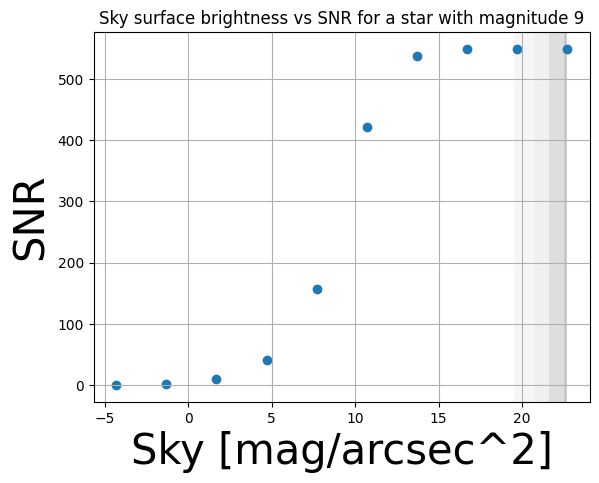

In [19]:
fig, ax = plt.subplots()

# Sky-surface-brightness bands (contiguous, using your ranges)
bands = [
    (22.5, 22.7, {'facecolor': '#2b2b2b', 'alpha': 0.25, 'label': 'Dark 22.5–22.7'}),
    (21.6, 22.5, {'facecolor': '#5a5a5a', 'alpha': 0.20, 'label': 'Dark gray 21.6–22.5'}),
    (20.7, 21.6, {'facecolor': '#b5b5b5', 'alpha': 0.20, 'label': 'Light gray 20.7–21.6'}),
    (19.5, 20.7, {'facecolor': '#e8e8e8', 'alpha': 0.35, 'label': 'Almost white 19.5–20.7'}),
]

# draw bands
for x0, x1, style in bands:
    ax.axvspan(x0, x1, **{k: v for k, v in style.items() if k != 'label'})

plt.scatter(mu_mag_as, (np.asarray(SNR2)).ravel())
plt.grid(True)
plt.title("Sky surface brightness vs SNR for a star with magnitude 9")
#Dark 22.5-22.7
#Dark gray 22.4 -21.6
# Light gray 21.6-20.7 
# Some white but not really white for 20.7 to 19.5
plt.xlabel('Sky [mag/arcsec^2]', size='30')
plt.ylabel('SNR', size='30')

Text(0, 0.5, 'SNR')

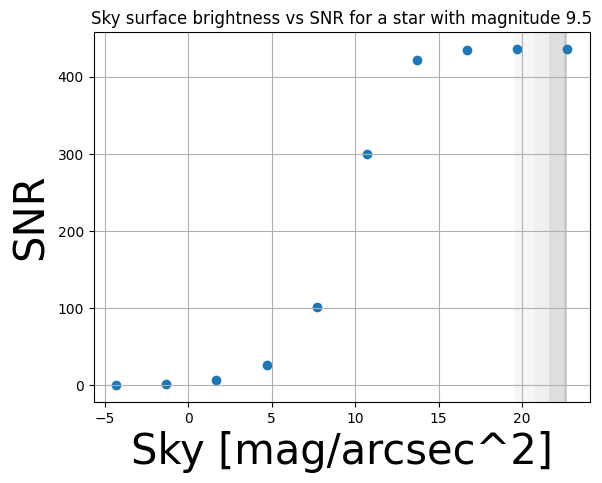

In [20]:
fig, ax = plt.subplots()

# Sky-surface-brightness bands (contiguous, using your ranges)
bands = [
    (22.5, 22.7, {'facecolor': '#2b2b2b', 'alpha': 0.25, 'label': 'Dark 22.5–22.7'}),
    (21.6, 22.5, {'facecolor': '#5a5a5a', 'alpha': 0.20, 'label': 'Dark gray 21.6–22.5'}),
    (20.7, 21.6, {'facecolor': '#b5b5b5', 'alpha': 0.20, 'label': 'Light gray 20.7–21.6'}),
    (19.5, 20.7, {'facecolor': '#e8e8e8', 'alpha': 0.35, 'label': 'Almost white 19.5–20.7'}),
]

# draw bands
for x0, x1, style in bands:
    ax.axvspan(x0, x1, **{k: v for k, v in style.items() if k != 'label'})

plt.scatter(mu_mag_as, (np.asarray(SNR3)).ravel())
plt.grid(True)
plt.title("Sky surface brightness vs SNR for a star with magnitude 9.5")
#Dark 22.5-22.7
#Dark gray 22.4 -21.6
# Light gray 21.6-20.7 
# Some white but not really white for 20.7 to 19.5
plt.xlabel('Sky [mag/arcsec^2]', size='30')
plt.ylabel('SNR', size='30')

In [21]:
## With prof 

In [22]:
# We'll compute star counts (electrons) for a range of magnitudes using the user's slide parameters.
# This notebook cell defines reusable functions and then prints a table for the magnitudes shown in the image.

import numpy as np
import pandas as pd
from math import pi

# Physical constants
h = 6.626e-27     # Planck [erg*s]
c = 2.998e10      # speed of light [cm/s]

def telescope_area(diam_cm: float) -> float:
    """Geometric collecting area in cm^2 for a circular aperture of diameter diam_cm (cm)."""
    return pi * (diam_cm / 2)**2

def photon_energy(lam_A: float) -> float:
    """Photon energy (erg) at wavelength lam_A (Angstrom)."""
    lam_cm = lam_A * 1e-8
    return h * c / lam_cm

def star_counts_electrons(
    mag: float,
    F_lambda0: float = 3.6e-9,   # V band zeropoint [erg/cm^2/s/Å]
    lam_A: float = 5500,       # central wavelength [Å]
    dlam_A: float = 869,       # bandwidth [Å] ~ V
    diam_cm: float = 350,      # telescope diameter [cm]
    eta: float = 0.7,            # overall efficiency
    t_exp_s: float = 100,      # exposure time [s]
    extinction_mag_per_airmass: float = 0.2,  # mag/airmass
    airmass: float = 1.2,        # airmass
) -> float:
    """
    Return total detected electrons from a star of magnitude 'mag' in exposure t_exp_s
    using an F_lambda zeropoint. Includes atmospheric extinction as mag += k * X.
    """
    # Geometric area
    A = telescope_area(diam_cm)
    # Effective observed magnitude (add atmospheric extinction in magnitudes)
    mag_eff = mag #+ extinction_mag_per_airmass * airmass
    # Flux density [erg/cm^2/s/Å] for the star at the ground
    F_lambda = F_lambda0 * 10**(-0.4 * mag_eff)
    # Integrated energy flux over the band
    F_band = F_lambda * dlam_A
    # Photon rate at the top of the detector per cm^2
    E_ph = photon_energy(lam_A)
    N_gamma_cm2_s = F_band / E_ph
    # Detected electrons
    e_detected = N_gamma_cm2_s * A * eta * t_exp_s
    return e_detected

# Reproduce the table for magnitudes seen in the screenshot
mags = [5,10,15,16,17,18,19,20,21,22,23,24,25]
counts = [round(star_counts_electrons(m)) for m in mags]

df = pd.DataFrame({"mag": mags, "star_electrons": counts})
df


,mag,star_electrons
0,5,58334558693
1,10,583345587
2,15,5833456
3,16,2322341
4,17,924540
5,18,368066
6,19,146530
7,20,58335
8,21,23223
9,22,9245


In [23]:
def sky_counts(mu_mag_as2=21.0, F_lambda0=3.6e-9, lam_A=5500, dlam_A=869,
               diam_cm=350, eta=0.7, t_exp_s=100.0, ap_radius_as=2.0):
    A = pi*(diam_cm/2)**2                       # cm^2
    F_lambda = F_lambda0 * 10**(-0.4*mu_mag_as2) # erg/cm^2/s/Å/arcsec^2
    F_band   = F_lambda * dlam_A                 # erg/cm^2/s/arcsec^2
    E_ph     = h*c/(lam_A*1e-8)                  # erg
    N_sky    = F_band/E_ph                       # ph/cm^2/s/arcsec^2
    Omega    = pi*ap_radius_as**2                # arcsec^2
    sky_e_ap = N_sky * Omega * A * eta * t_exp_s
    return sky_e_ap
sky_e_ap = sky_counts()

In [29]:
sky_e_ap

291833.92806548666

SyntaxError: unexpected character after line continuation character (2626371900.py, line 1)